# CIFAR-10 Image Classification with CNN

Image classification is a foundational challenge in computer vision aimed at assigning input images to predefined categories. This project builds a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset, which consists of 60,000 images across 10 distinct classes. The scope encompasses exploratory data analysis, preprocessing, CNN architecture design, and comprehensive model performance evaluation.

<img src='https://cdn.prod.website-files.com/6391b5b30283a58cafb3bb77/666064accaa40bdeecdb530f_innv-CNN.webp' widt='400'>

In [1]:
#Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split

In [2]:
# Load CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [4]:
# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 Classes:")
print(class_names)

CIFAR-10 Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


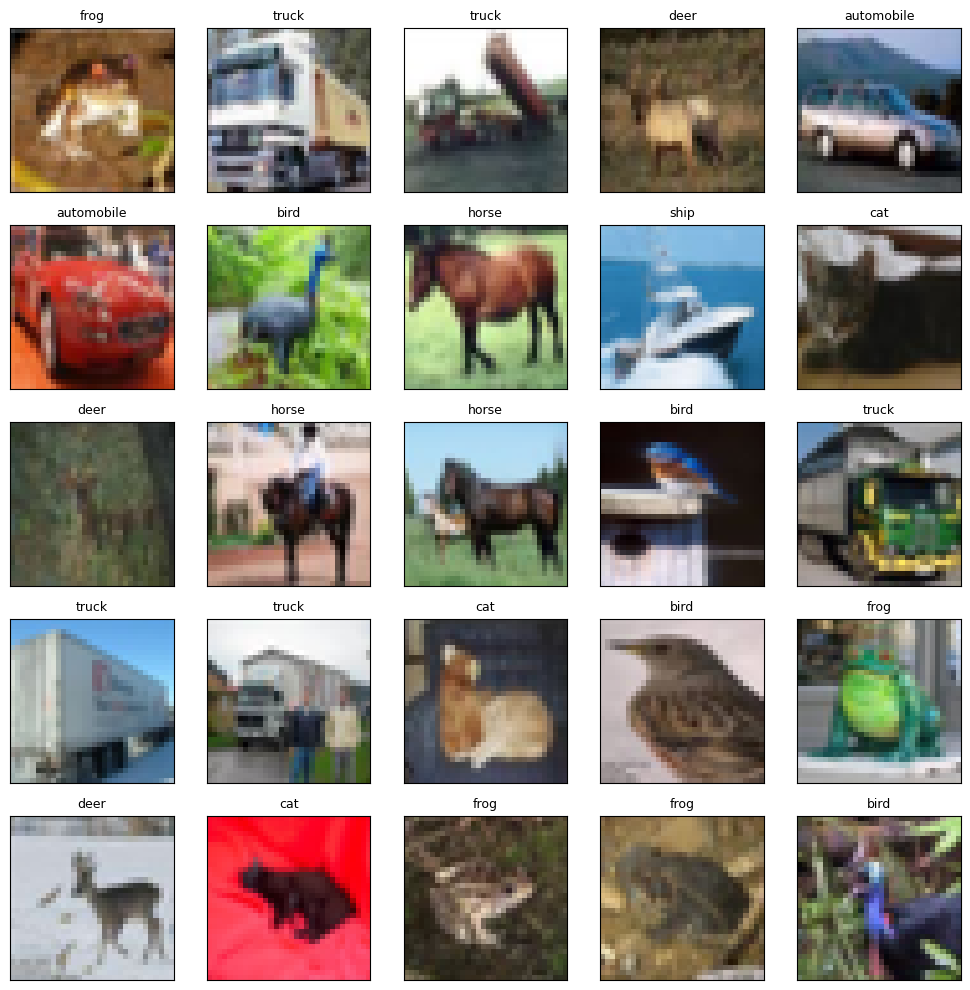

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=9)

plt.tight_layout()
plt.show()

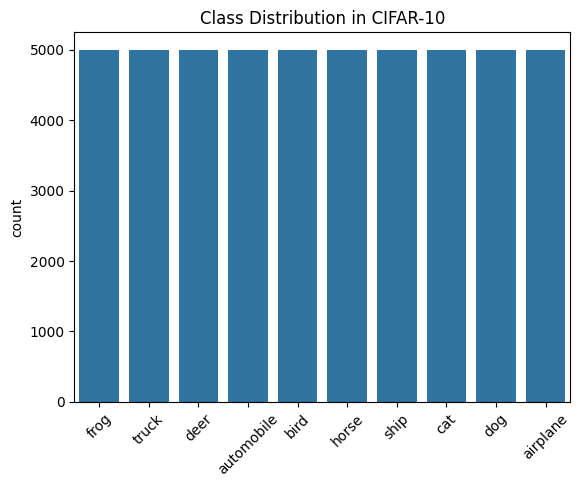

In [7]:
import seaborn as sns

# Map class indices to class names and plot directly
labels = [class_names[i[0]] for i in y_train]

sns.countplot(x=labels)
plt.xticks(rotation=45)
plt.title("Class Distribution in CIFAR-10")
plt.show()

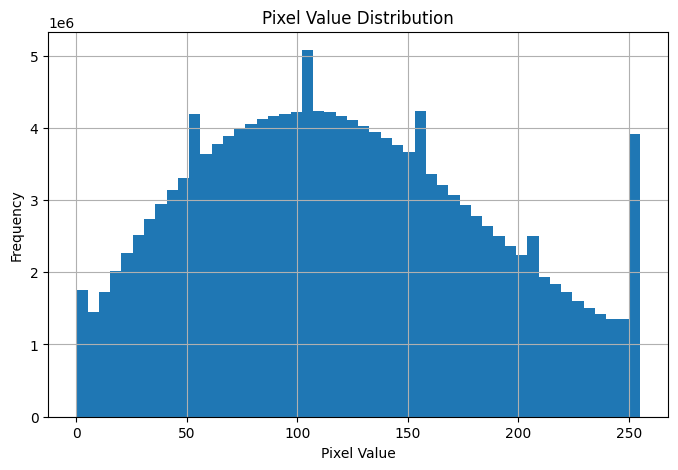

In [9]:
import pandas as pd
pd.Series(x_train.flatten()).hist(bins=50, figsize=(8, 5))
plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### Train Validation Split

In [10]:
x_train, x_valid, y_train, y_valid = train_test_split(x_train,y_train,test_size=0.1,random_state=42)

In [11]:
print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nValidation Images Shape: ', x_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (45000, 32, 32, 3)
Train Labels Shape:       (45000, 1)

Validation Images Shape:  (5000, 32, 32, 3)
Validation Labels Shape:  (5000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


In [12]:
# convert pixel values to float
x_train = x_train.astype("float32")
x_valid = x_valid.astype("float32")
x_test  = x_test.astype("float32")

# normalization
x_train = x_train / 255.0
x_valid = x_valid / 255.0
x_test  = x_test / 255.0

In [13]:
print("Train min:", x_train.min(), "Train max:", x_train.max())
print("Valid min:", x_valid.min(), "Valid max:", x_valid.max())
print("Test  min:", x_test.min(),  "Test  max:", x_test.max())

Train min: 0.0 Train max: 1.0
Valid min: 0.0 Valid max: 1.0
Test  min: 0.0 Test  max: 1.0


### One -Hot Encoding Label

In [14]:
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test  = to_categorical(y_test, 10)

In [15]:
"y_train shape:", y_train.shape
"Example label:", y_train[0]

('Example label:', array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]))

In [16]:
datagen = ImageDataGenerator(
    
    rotation_range=15,
    
    width_shift_range=0.1,
    
    height_shift_range=0.1,
    
    horizontal_flip=True,
    
    zoom_range=0.1
    
)

In [17]:
datagen.fit(x_train)

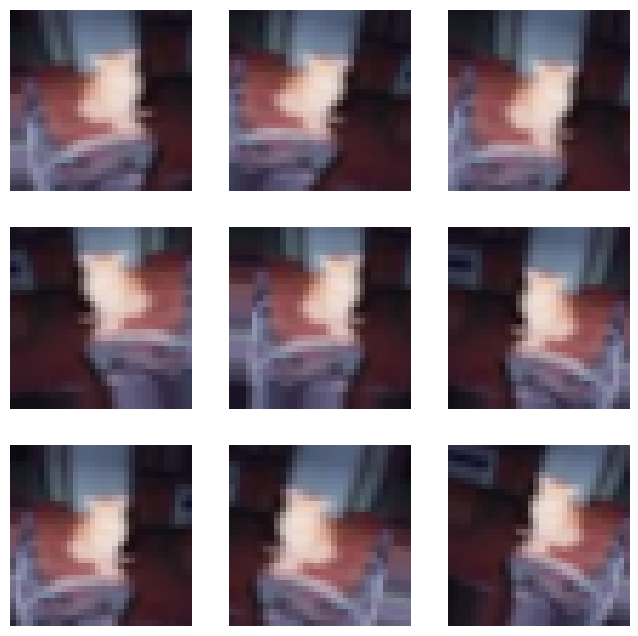

In [18]:
## Augmented Image Sample 
sample_image = x_train[0].reshape((1,32,32,3))

plt.figure(figsize=(8,8))

i = 0
for batch in datagen.flow(sample_image, batch_size=1):
    
    plt.subplot(3,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")
    
    i += 1
    if i == 9:
        break

plt.show()

### Modeling

In [19]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

# Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.40))
model.add(Dense(10, activation="softmax"))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [21]:
early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=5,min_lr=1e-5)

In [22]:
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),validation_data=(x_valid, y_valid),epochs=50,callbacks=[early_stop, lr_reduce])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - accuracy: 0.4035 - loss: 1.7146 - val_accuracy: 0.5454 - val_loss: 1.2456 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.5561 - loss: 1.2414 - val_accuracy: 0.6324 - val_loss: 1.0427 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 145ms/step - accuracy: 0.6300 - loss: 1.0545 - val_accuracy: 0.7118 - val_loss: 0.8163 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.6661 - loss: 0.9543 - val_accuracy: 0.6920 - val_loss: 0.8949 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.6910 - loss: 0.8887 - val_accuracy: 0.6530 - val_loss: 1.0829 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.7110 - loss: 0.8316 - val_accuracy: 0.6918 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 143ms/step - accura

In [23]:
model.save("cifar10_cnn_model.keras")

In [24]:
import pickle

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

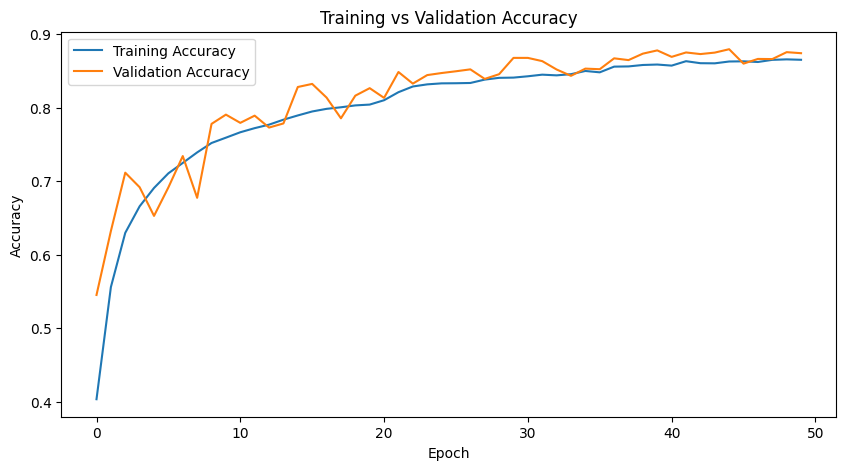

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

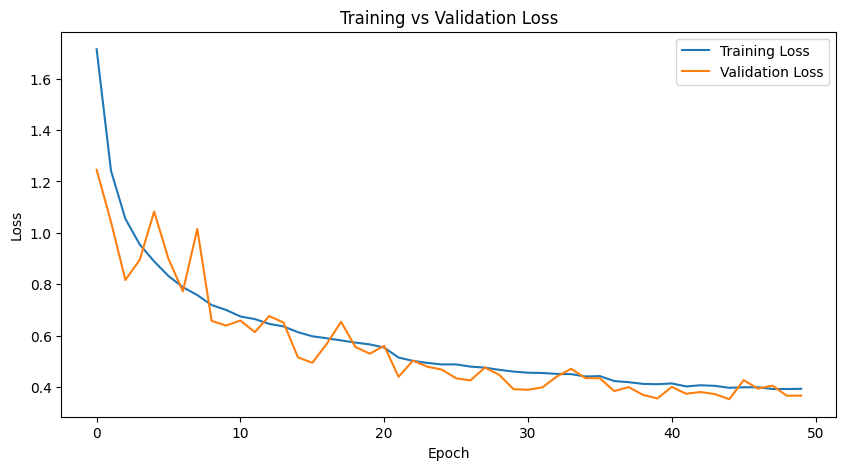

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8747 - loss: 0.3780
Test Loss: 0.3780457675457001
Test Accuracy: 0.8747000098228455


In [28]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


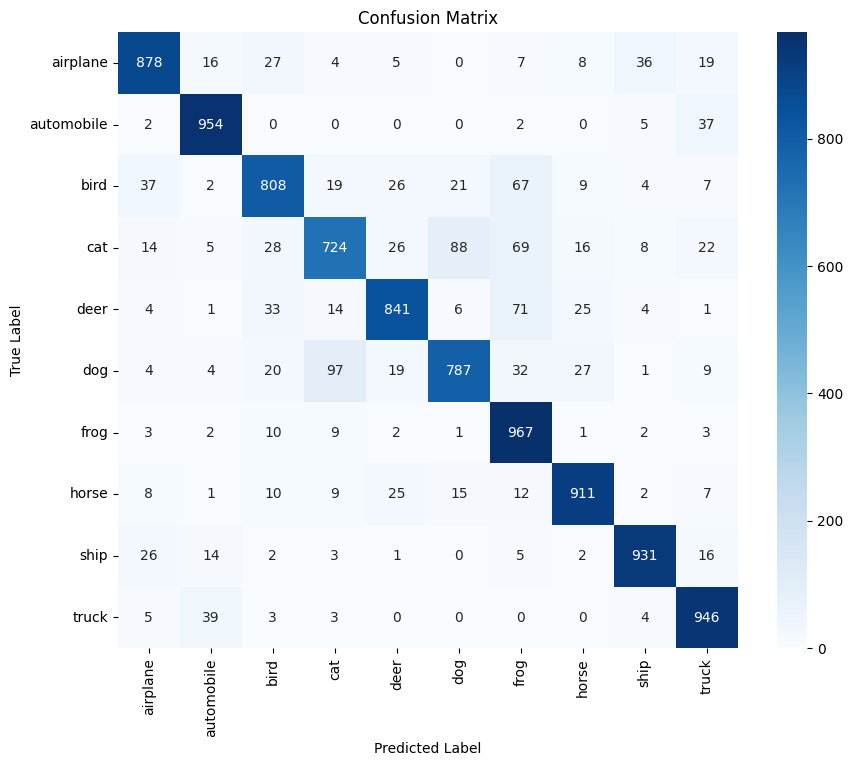

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [30]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


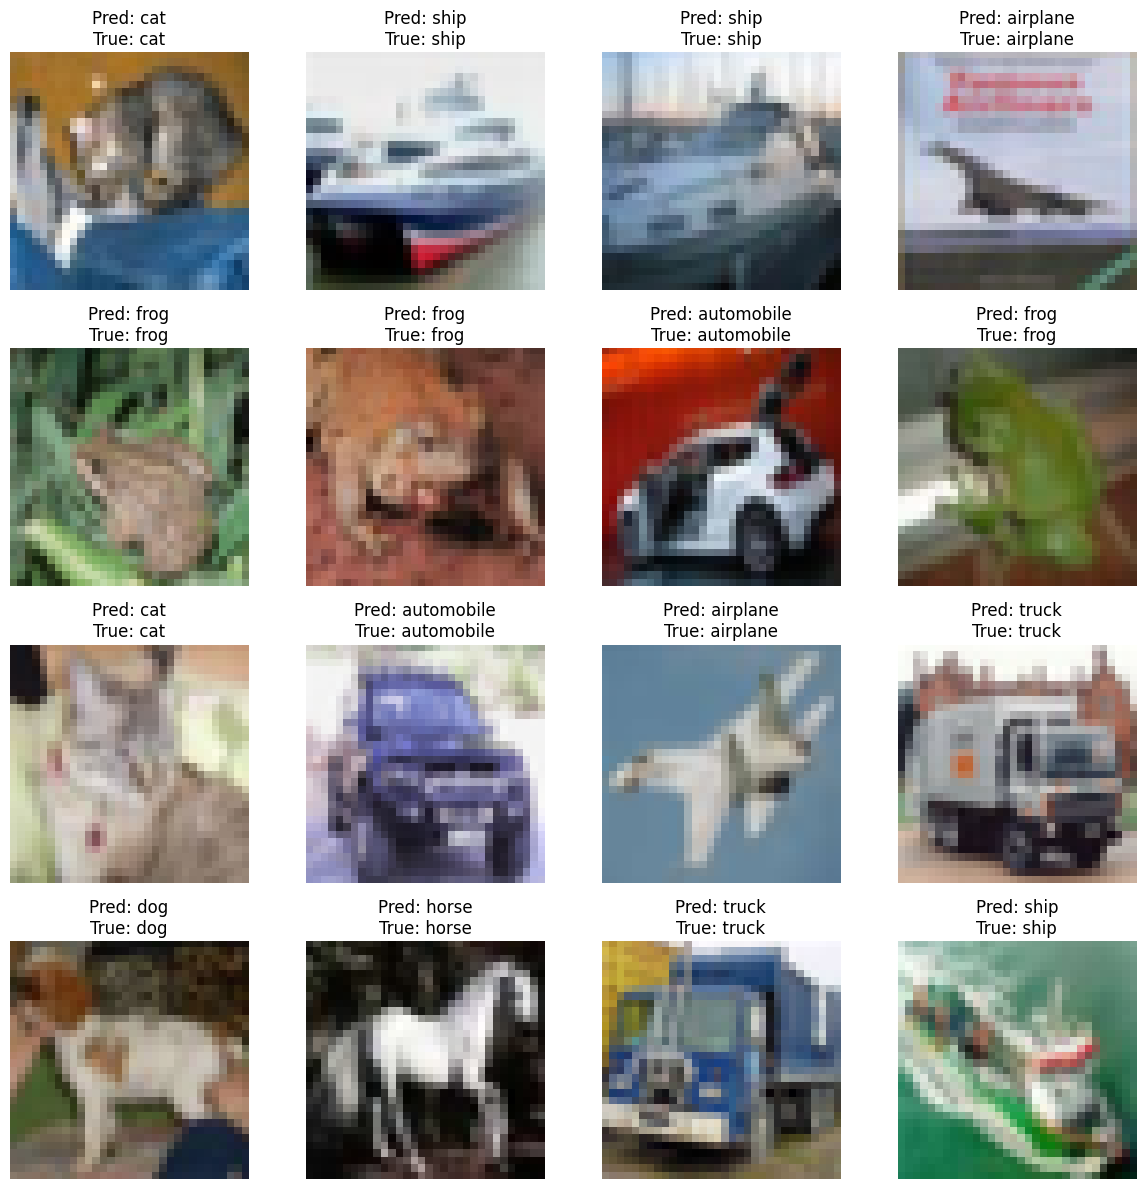

In [31]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(x_test[i])

    pred = class_names[predicted_classes[i]]
    true = class_names[true_classes[i]]

    plt.title(f"Pred: {pred}\nTrue: {true}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In this project, a Convolutional Neural Network (CNN) was developed using the CIFAR-10 dataset. The architecture consists of multiple convolutional layers combined with Batch Normalization, MaxPooling and Dropout layers. During training, techniques such as Data Augmentation, Early Stopping and ReduceLROnPlateau were applied to improve the model’s generalization capability. The final model achieved approximately 87% accuracy on the test dataset. The confusion matrix analysis indicates that the model successfully learned meaningful visual patterns for most classes. Further improvements can be achieved using Transfer Learning techniques such as ResNet, EfficientNet or MobileNet. Using pretrained deep networks, the performance can potentially reach 90%+ accuracy.